# Corpus EDA — Dolma Sample (seed 42)

Distribution analysis of the 1,072-document annotation corpus. Token counts use `bert-base-uncased`. Noise status (`is_noise`) is shown throughout rather than filtered.

In [11]:
import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

NOISE_PALETTE = {True: '#d62728', False: '#1f77b4'}
NOISE_LABELS  = {True: 'Noise', False: 'Non-noise'}

In [ ]:
from nb_utils import load

FEATURES_CSV = '../features/features.csv'


In [ ]:
# corpus.parquet already has the numeric coercions and is_noise typing applied
# by the exporter. dolma_source/dolma_shard are the canonical names (see
# narradolma-catalog/SCHEMA.md); alias them back to the short forms this
# notebook uses.
df = load('corpus').rename(columns={'dolma_source': 'source',
                                    'dolma_shard':  'shard',
                                    'dolma_id':     'id'})

feat = pd.read_csv(FEATURES_CSV)
df = df.merge(feat, on='safe_instance_id', how='left')

unknown_mask = df['topic_classification'] == 'Unknown'
df.loc[unknown_mask, 'topic_classification'] = (
    'Shard: ' + df.loc[unknown_mask, 'source'].str.title()
)

print(f'Total rows:  {len(df)}')
print(f'  Noise:     {df.is_noise.sum()} ({df.is_noise.mean()*100:.1f}%)')
print(f'  Non-noise: {(~df.is_noise).sum()} ({(~df.is_noise).mean()*100:.1f}%)')
print(f'  Columns:   {list(df.columns)}')


In [14]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
df['bert_tokens'] = df['sampled_text'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=False))
)
print('BERT token stats (sampled_text):')
print(df['bert_tokens'].describe().round(1))

BERT token stats (sampled_text):
count    1072.0
mean       81.4
std        31.8
min        12.0
25%        60.0
50%        73.0
75%        95.0
max       200.0
Name: bert_tokens, dtype: float64


## 1. Overview

In [15]:
summary = {
    'Total documents':   len(df),
    'Noise (True)':      int(df['is_noise'].sum()),
    'Non-noise (False)': int((~df['is_noise']).sum()),
    'Unique folders':    df['folder'].nunique(),
    'Unique topics':     df['topic_classification'].nunique(),
    'Unique sources':    df['source'].nunique(),
    'Unique shards':     df['shard'].nunique(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Count'])

,Count
Total documents,1072
Noise (True),188
Non-noise (False),884
Unique folders,12
Unique topics,28
Unique sources,7
Unique shards,11


## 2. Noise distribution

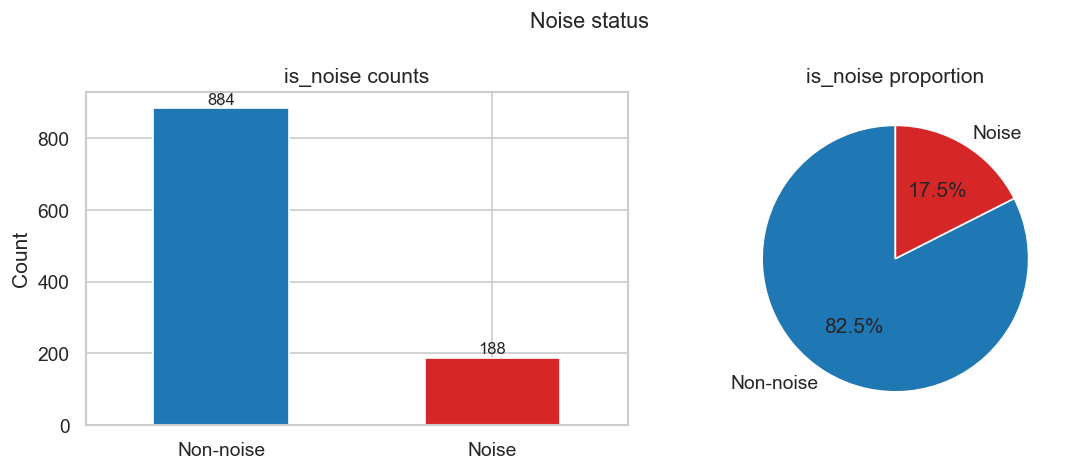

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

noise_counts = df['is_noise'].value_counts().rename(NOISE_LABELS)
colors = [NOISE_PALETTE[k] for k in df['is_noise'].value_counts().index]
noise_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('is_noise counts')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

axes[1].pie(noise_counts, labels=noise_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('is_noise proportion')

plt.suptitle('Noise status', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Folder distribution

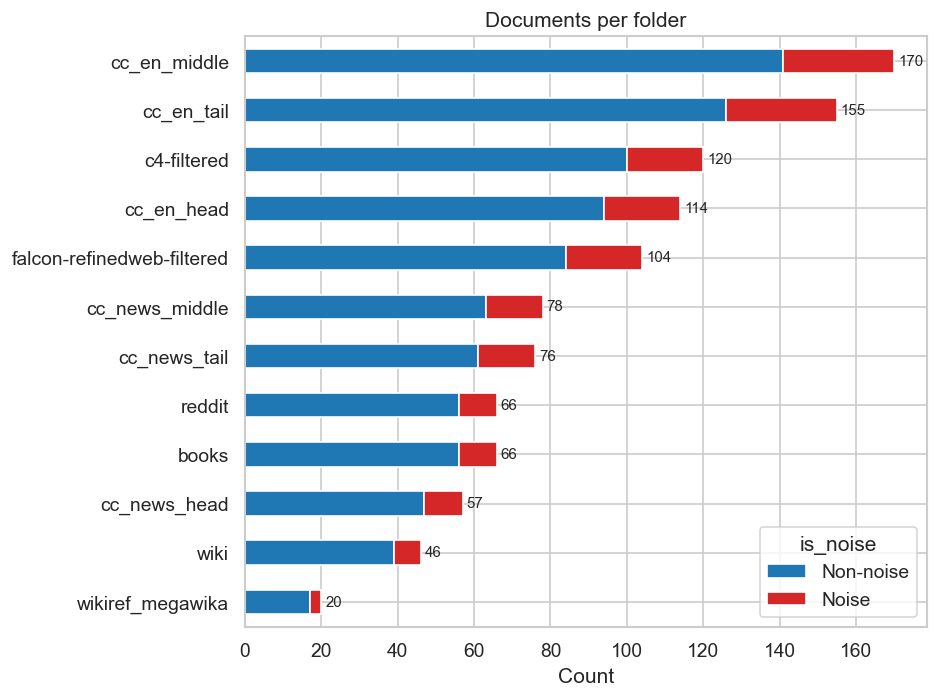

is_noise                    Non-noise  Noise  Total
folder                                             
cc_en_middle                      141     29    170
cc_en_tail                        126     29    155
c4-filtered                       100     20    120
cc_en_head                         94     20    114
falcon-refinedweb-filtered         84     20    104
cc_news_middle                     63     15     78
cc_news_tail                       61     15     76
books                              56     10     66
reddit                             56     10     66
cc_news_head                       47     10     57
wiki                               39      7     46
wikiref_megawika                   17      3     20


In [7]:
folder_noise = (df.groupby(['folder', 'is_noise'])
               .size().unstack(fill_value=0)
               .rename(columns=NOISE_LABELS))
folder_noise['Total'] = folder_noise.sum(axis=1)
folder_noise = folder_noise.sort_values('Total', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
folder_noise[['Non-noise', 'Noise']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[NOISE_PALETTE[False], NOISE_PALETTE[True]], edgecolor='white'
)
ax.set_title('Documents per folder')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, total in enumerate(folder_noise['Total']):
    ax.text(total + 1, i, str(total), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(folder_noise[['Non-noise', 'Noise', 'Total']].sort_values('Total', ascending=False))

## 4. Topic distribution

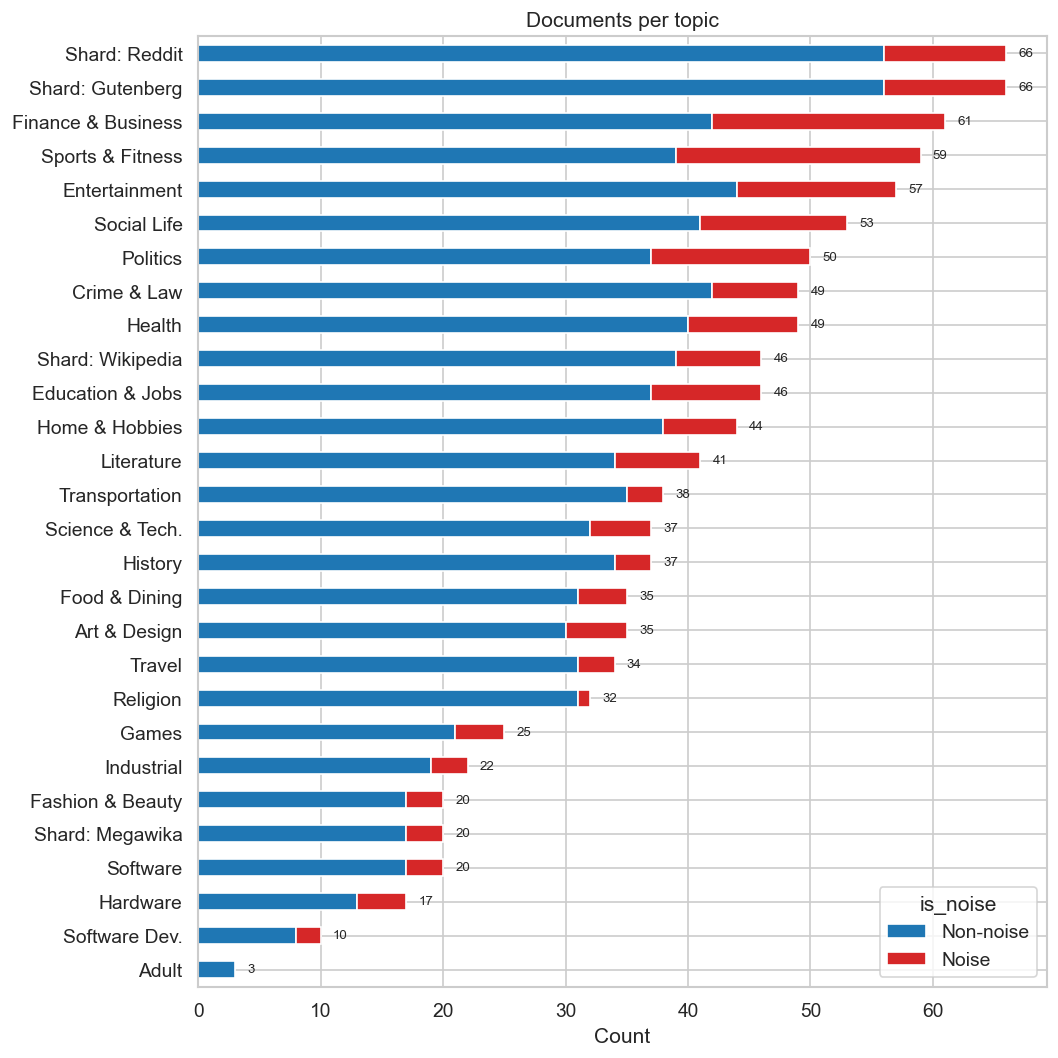

is_noise              Non-noise  Noise  Total
topic_classification                         
Shard: Reddit                56     10     66
Shard: Gutenberg             56     10     66
Finance & Business           42     19     61
Sports & Fitness             39     20     59
Entertainment                44     13     57
Social Life                  41     12     53
Politics                     37     13     50
Crime & Law                  42      7     49
Health                       40      9     49
Shard: Wikipedia             39      7     46
Education & Jobs             37      9     46
Home & Hobbies               38      6     44
Literature                   34      7     41
Transportation               35      3     38
Science & Tech.              32      5     37
History                      34      3     37
Food & Dining                31      4     35
Art & Design                 30      5     35
Travel                       31      3     34
Religion                     31   

In [8]:
topic_noise = (df.groupby(['topic_classification', 'is_noise'])
               .size().unstack(fill_value=0)
               .rename(columns=NOISE_LABELS))
topic_noise['Total'] = topic_noise.sum(axis=1)
topic_noise = topic_noise.sort_values('Total', ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
topic_noise[['Non-noise', 'Noise']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[NOISE_PALETTE[False], NOISE_PALETTE[True]], edgecolor='white'
)
ax.set_title('Documents per topic')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, total in enumerate(topic_noise['Total']):
    ax.text(total + 1, i, str(total), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(topic_noise[['Non-noise', 'Noise', 'Total']].sort_values('Total', ascending=False))

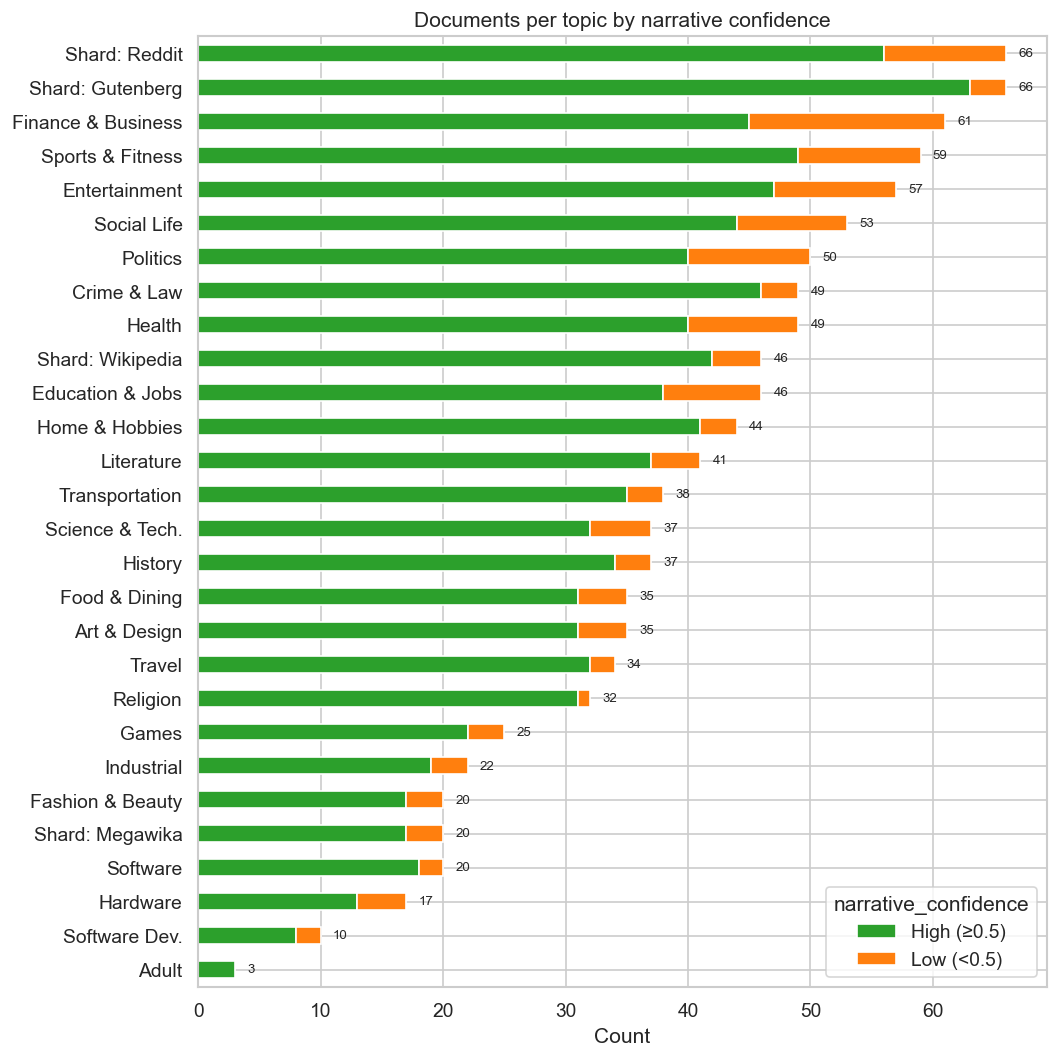

narrative_confidence  High (≥0.5)  Low (<0.5)  Total
topic_classification                                
Shard: Reddit                  56          10     66
Shard: Gutenberg               63           3     66
Finance & Business             45          16     61
Sports & Fitness               49          10     59
Entertainment                  47          10     57
Social Life                    44           9     53
Politics                       40          10     50
Crime & Law                    46           3     49
Health                         40           9     49
Shard: Wikipedia               42           4     46
Education & Jobs               38           8     46
Home & Hobbies                 41           3     44
Literature                     37           4     41
Transportation                 35           3     38
Science & Tech.                32           5     37
History                        34           3     37
Food & Dining                  31           4 

In [9]:
NAR_PALETTE = {'High (≥0.5)': '#2ca02c', 'Low (<0.5)': '#ff7f0e'}

nar_conf_group = df['narrative_confidence'].apply(
    lambda x: 'High (≥0.5)' if pd.notna(x) and x >= 0.5 else 'Low (<0.5)'
)
topic_nar = (df.groupby(['topic_classification', nar_conf_group])
               .size().unstack(fill_value=0))
for col in ['High (≥0.5)', 'Low (<0.5)']:
    if col not in topic_nar.columns:
        topic_nar[col] = 0
topic_nar['Total'] = topic_nar.sum(axis=1)
topic_nar = topic_nar.sort_values('Total', ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
topic_nar[['High (≥0.5)', 'Low (<0.5)']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[NAR_PALETTE['High (≥0.5)'], NAR_PALETTE['Low (<0.5)']], edgecolor='white'
)
ax.set_title('Documents per topic by narrative confidence')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, total in enumerate(topic_nar['Total']):
    ax.text(total + 1, i, str(total), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(topic_nar[['High (≥0.5)', 'Low (<0.5)', 'Total']].sort_values('Total', ascending=False))

## 5. Narrative label & confidence

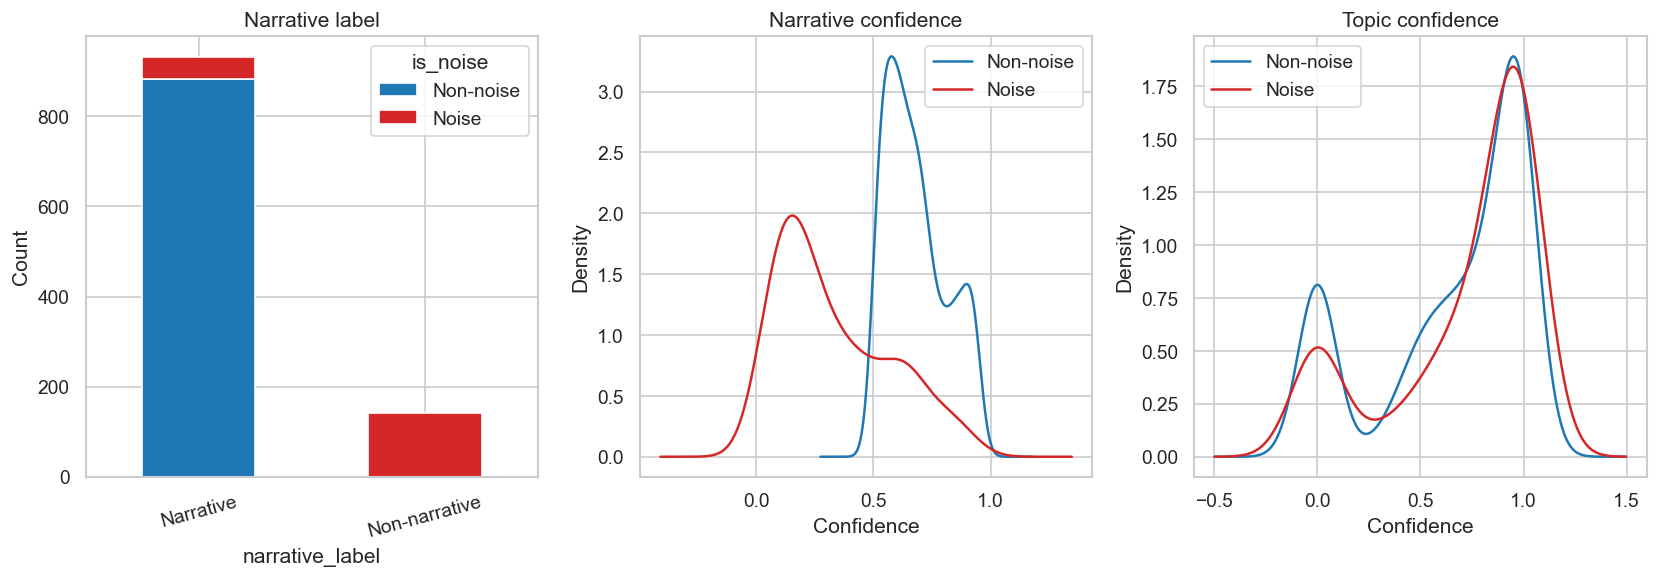

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# narrative label stacked bar
nar_noise = (df.groupby(['narrative_label', 'is_noise'])
             .size().unstack(fill_value=0)
             .rename(columns=NOISE_LABELS))
nar_noise[['Non-noise', 'Noise']].plot(
    kind='bar', ax=axes[0], stacked=True,
    color=[NOISE_PALETTE[False], NOISE_PALETTE[True]], edgecolor='white'
)
axes[0].set_title('Narrative label')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylabel('Count')

# narrative confidence KDE
for nv, lbl, clr in [(False, 'Non-noise', NOISE_PALETTE[False]),
                      (True,  'Noise',     NOISE_PALETTE[True])]:
    (df[df.is_noise == nv]['narrative_confidence']
       .dropna().plot(kind='kde', ax=axes[1], label=lbl, color=clr))
axes[1].set_title('Narrative confidence')
axes[1].set_xlabel('Confidence')
axes[1].legend()

# topic confidence KDE
for nv, lbl, clr in [(False, 'Non-noise', NOISE_PALETTE[False]),
                      (True,  'Noise',     NOISE_PALETTE[True])]:
    (df[df.is_noise == nv]['topic_confidence']
       .dropna().plot(kind='kde', ax=axes[2], label=lbl, color=clr))
axes[2].set_title('Topic confidence')
axes[2].set_xlabel('Confidence')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Token length (BERT, sampled_text)

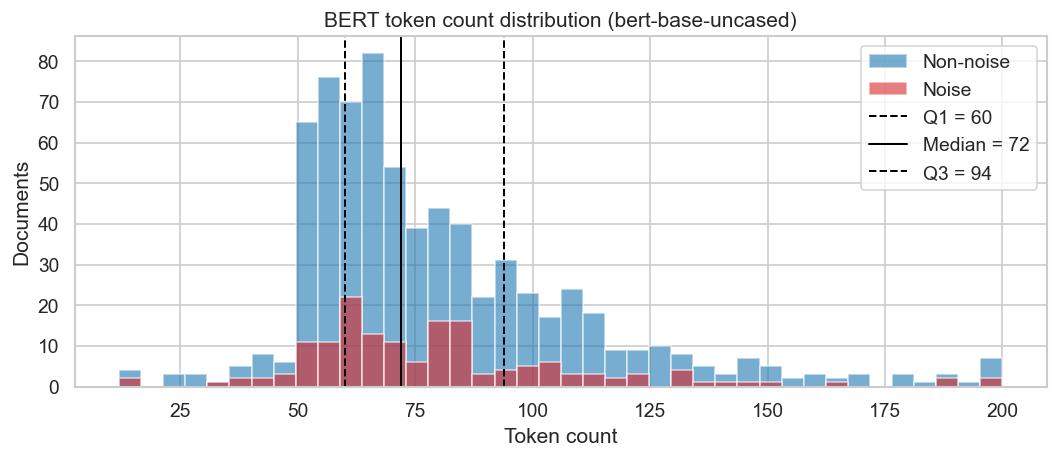

           count  mean   std   min   25%   50%   75%    max
is_noise                                                   
Non-noise  716.0  80.3  30.9  12.0  59.0  72.0  94.0  200.0
Noise      158.0  80.4  31.4  12.0  61.0  74.5  90.0  200.0


In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

for nv, lbl, clr in [(False, 'Non-noise', NOISE_PALETTE[False]),
                      (True,  'Noise',     NOISE_PALETTE[True])]:
    ax.hist(df[df.is_noise == nv]['bert_tokens'], bins=40,
            alpha=0.6, label=lbl, color=clr, edgecolor='white')

for q, ls, lbl in [(0.25, '--', 'Q1'), (0.50, '-', 'Median'), (0.75, '--', 'Q3')]:
    val = df['bert_tokens'].quantile(q)
    ax.axvline(val, color='black', linestyle=ls, linewidth=1.2,
               label=f'{lbl} = {val:.0f}')

ax.set_title('BERT token count distribution (bert-base-uncased)')
ax.set_xlabel('Token count')
ax.set_ylabel('Documents')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('is_noise')['bert_tokens']
      .describe().rename(index=NOISE_LABELS).round(1))

## 7. Automatic features

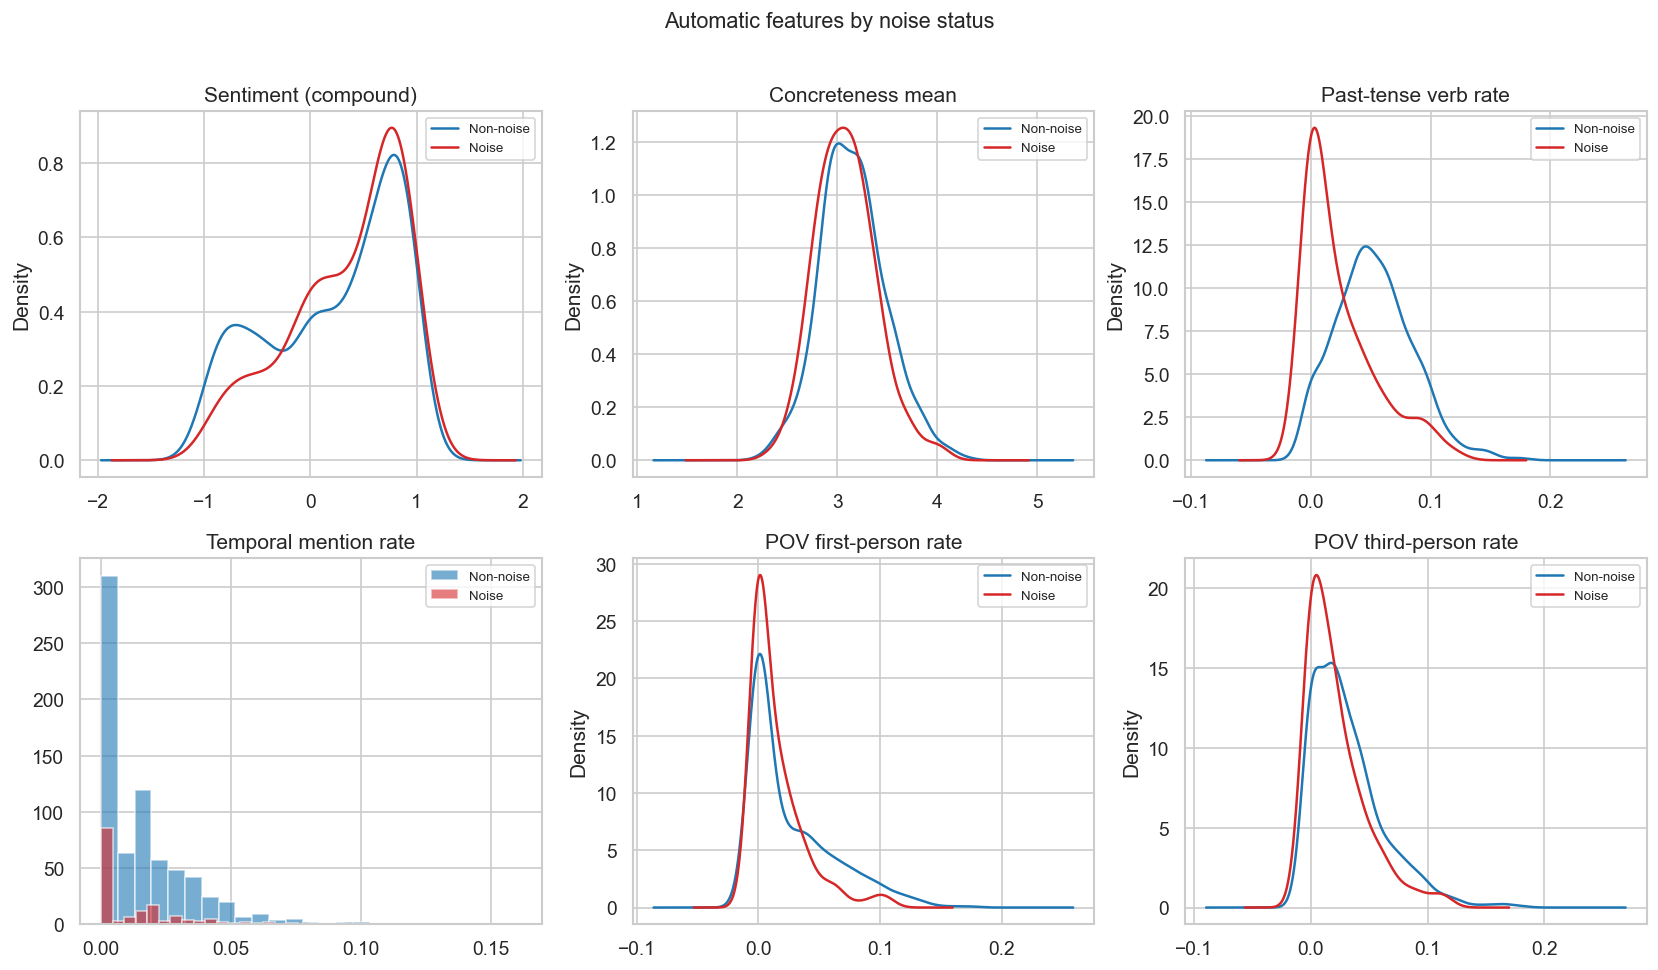

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

feature_configs = [
    ('sentiment_compound',    'Sentiment (compound)',     'kde'),
    ('concreteness_mean',     'Concreteness mean',        'kde'),
    ('past_tense_verb_rate',  'Past-tense verb rate',     'kde'),
    ('temporal_mention_rate', 'Temporal mention rate',    'hist'),
    ('pov_first_rate',        'POV first-person rate',    'kde'),
    ('pov_third_rate',        'POV third-person rate',    'kde'),
]

for ax, (col, title, ptype) in zip(axes.flat, feature_configs):
    for nv, lbl, clr in [(False, 'Non-noise', NOISE_PALETTE[False]),
                          (True,  'Noise',     NOISE_PALETTE[True])]:
        vals = df[df.is_noise == nv][col].dropna().astype(float)
        if ptype == 'kde':
            vals.plot(kind='kde', ax=ax, label=lbl, color=clr)
        else:
            ax.hist(vals, bins=25, alpha=0.6, label=lbl, color=clr, edgecolor='white')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Automatic features by noise status', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

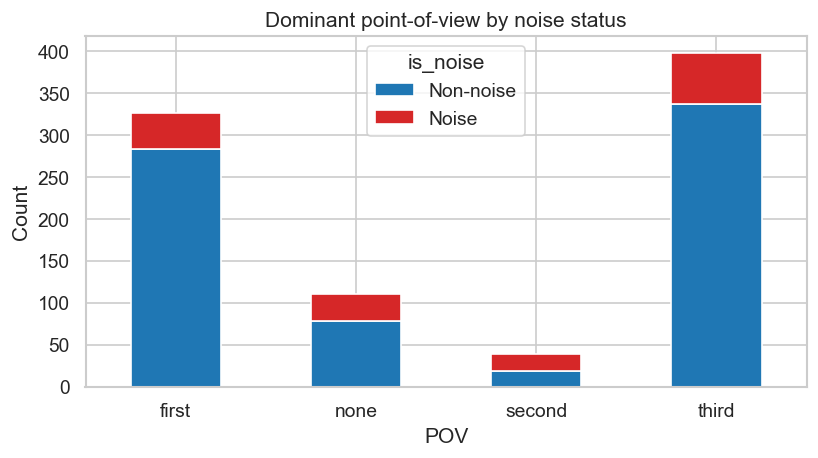

In [27]:
# Dominant POV bar chart
fig, ax = plt.subplots(figsize=(7, 4))
pov_noise = (df.groupby(['pov_dominant', 'is_noise'])
             .size().unstack(fill_value=0)
             .rename(columns=NOISE_LABELS))
pov_noise[['Non-noise', 'Noise']].plot(
    kind='bar', ax=ax, stacked=True,
    color=[NOISE_PALETTE[False], NOISE_PALETTE[True]], edgecolor='white'
)
ax.set_title('Dominant point-of-view by noise status')
ax.set_xlabel('POV')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 8. Event and verb counts

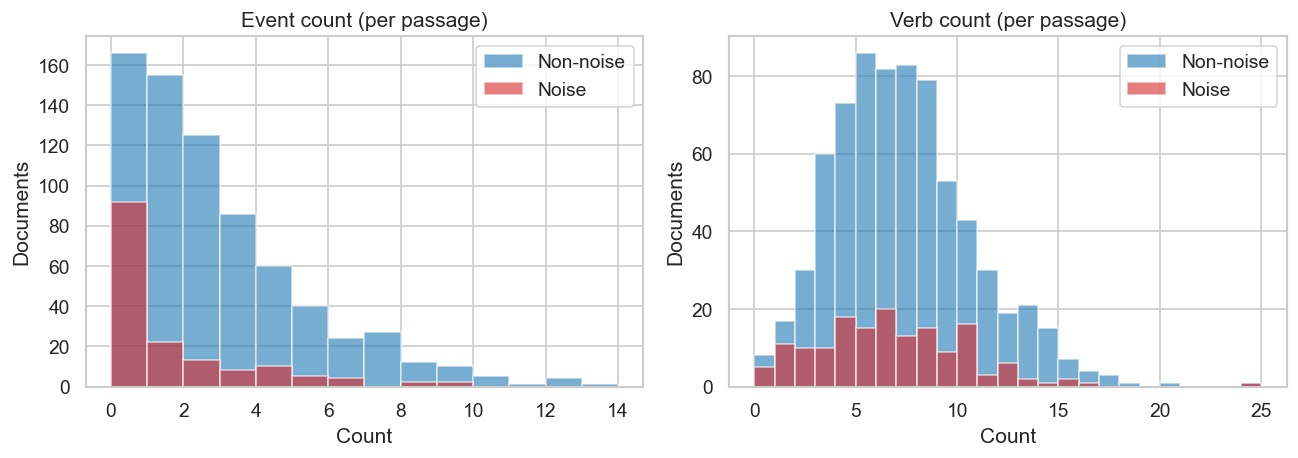

          event_count                                     verb_count       \
                count mean  std  min  25%  50%  75%   max      count mean   
is_noise                                                                    
Non-noise       716.0  2.4  2.4  0.0  1.0  2.0  4.0  13.0      716.0  6.9   
Noise           158.0  1.2  2.0  0.0  0.0  0.0  2.0   9.0      158.0  6.3   

                                          
           std  min  25%  50%  75%   max  
is_noise                                  
Non-noise  3.5  0.0  4.0  7.0  9.0  24.0  
Noise      3.8  0.0  4.0  6.0  9.0  24.0  


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(axes,
                           ['event_count', 'verb_count'],
                           ['Event count (per passage)', 'Verb count (per passage)']):
    max_val = int(df[col].dropna().astype(float).max())
    bins = list(range(0, max_val + 2))
    for nv, lbl, clr in [(False, 'Non-noise', NOISE_PALETTE[False]),
                          (True,  'Noise',     NOISE_PALETTE[True])]:
        vals = df[df.is_noise == nv][col].dropna().astype(float)
        ax.hist(vals, bins=bins, alpha=0.6, label=lbl, color=clr, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Documents')
    ax.legend()

plt.tight_layout()
plt.show()

print(df.groupby('is_noise')[['event_count', 'verb_count']]
      .describe().rename(index=NOISE_LABELS).round(1))

## 9. Correlation heatmap (numeric features)

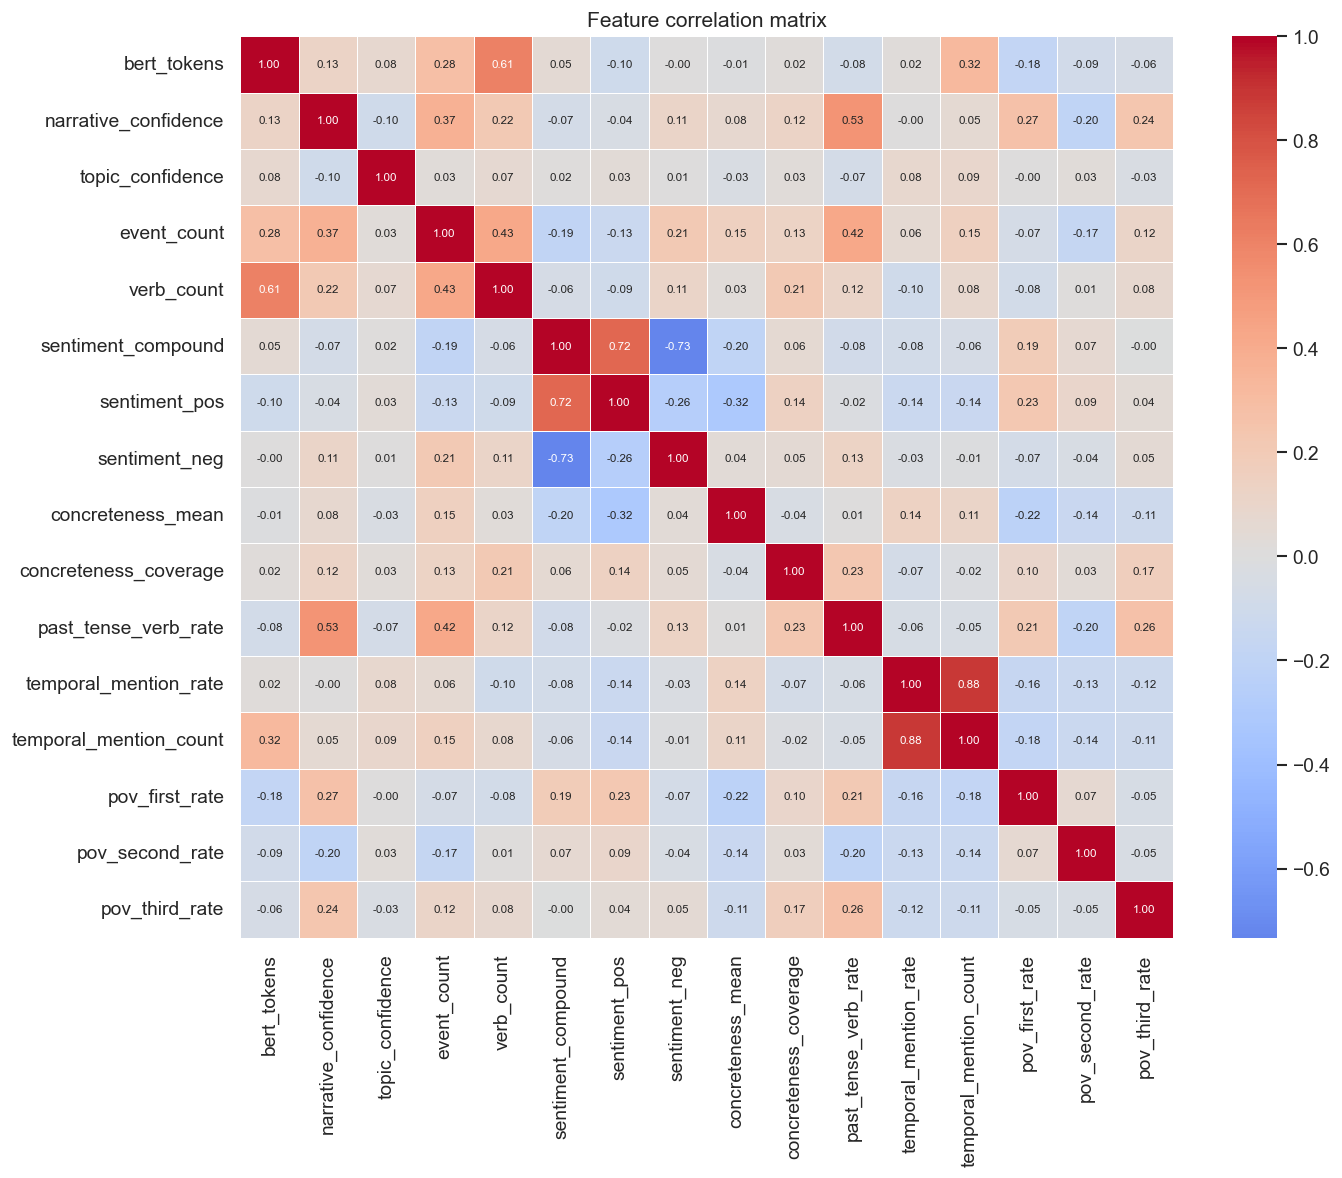

In [29]:
num_cols = [
    'bert_tokens', 'narrative_confidence', 'topic_confidence',
    'event_count', 'verb_count',
    'sentiment_compound', 'sentiment_pos', 'sentiment_neg',
    'concreteness_mean', 'concreteness_coverage',
    'past_tense_verb_rate', 'temporal_mention_rate', 'temporal_mention_count',
    'pov_first_rate', 'pov_second_rate', 'pov_third_rate',
]
corr = df[num_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()